# Laboratorio 2. Complejidad y búsqueda de hiperparámetros
### ISIS2611 · Aprendizaje de Máquina | Caso AlpesPlanck

**Integrantes:** (nombres completos y códigos)

**Grupo de entrega:** GL2

**Fecha límite:** 14 de septiembre, 20:00

---

> **Cómo usar este esqueleto.** Cada sección contiene una celda de texto que explica *qué* hay que hacer,
> *por qué* se hace y *qué* se debe justificar por escrito, seguida de una celda de código vacía con
> comentarios `# TODO`. Ninguna celda trae la solución. Antes de escribir código en una sección, conviene
> poder responder en voz alta la pregunta de control que aparece al final de cada bloque.
> Al terminar, elimina las notas marcadas como *"Nota del esqueleto"*, para que el notebook entregado se
> lea como un informe técnico y no como una guía.

## 0. Mapa del laboratorio y trazabilidad con la rúbrica

Antes de programar conviene ver el laboratorio completo, porque el peso de la nota no está donde suele
estar la atención. El código de los modelos vale 40 % y el análisis escrito vale 35 %.

| Sección del notebook | Actividad del enunciado | Criterio de rúbrica | Peso |
|:---|:---|:---|:---:|
| 1. Configuración, datos y protocolo de evaluación | Preparación previa | Transversal, soporta todos | 0 % directo |
| 2. Regresión polinomial con GridSearchCV | Actividad 1 | Criterio 1 | 15 % |
| 3. Curvas de validación | Actividad 2 | Se evalúa dentro de los criterios 1 y 6 | incluido |
| 4. Ridge y Lasso | Actividad 3 | Criterio 2 | 15 % |
| 5. Polinomial regularizado | Actividad 4 | Criterio 3 | 10 % |
| 6. Tabla comparativa y selección del mejor modelo | Actividad 5 | Criterio 4 | 5 % |
| 7. Intervalos de confianza por bootstrapping | Actividad 6 | Criterio 5 | 10 % |
| 8. Análisis de resultados | Sección "Análisis de resultados" | Criterio 6 | 35 % |
| 9. Video explicativo | Actividad 7 | Criterio 7 | 5 % |
| 10. Uso de herramientas de IA generativa | Reglas del curso | Criterio 8 | 5 % |

**Nota del esqueleto (importante).** La actividad 2, las curvas de validación, no tiene una fila propia
en la rúbrica. Eso no significa que se pueda omitir: es la evidencia gráfica que sostiene varias de las
preguntas del análisis, que sí valen 35 %. Omitirla cuesta puntos por dos vías, en el criterio 1 por
justificación incompleta y en el criterio 6 por respuestas sin soporte.

**Segunda observación.** El criterio 6 vale más que cualquier modelo individual. Un notebook con cuatro
modelos impecables y respuestas de dos líneas obtiene menos nota que uno con modelos correctos y un
análisis bien argumentado. Reserva tiempo real para la sección 8.

---
## 1. Configuración, datos y protocolo de evaluación

Esta sección no aparece en la rúbrica, pero condiciona la validez de todo lo demás. Si la partición o
el esquema de validación están mal planteados, todos los números posteriores quedan invalidados aunque
el código corra sin errores.

### 1.1 Importación de librerías

**Qué hacer.** Importar en una sola celda todo lo que se usará en el notebook, agrupado por origen:
manipulación de datos, visualización, y los componentes de scikit-learn (partición, validación cruzada,
búsqueda de hiperparámetros, curvas de validación, transformadores de preprocesamiento, escaladores,
generación de características polinomiales, los tres estimadores lineales y las métricas de regresión).

**Por qué en una sola celda.** Un lector, y el profesor, debe poder reconstruir el entorno leyendo una
celda. Las importaciones dispersas a lo largo del notebook dificultan la revisión y suelen producir
errores al reejecutar desde cero.

**Qué agregar aquí también.** La fijación de una semilla global y una constante `RANDOM_STATE` que se
reutilice en cada partición, en cada `KFold` y en cada remuestreo. Sin semilla fija, los resultados
cambian entre ejecuciones y las conclusiones del análisis dejan de ser verificables.

In [3]:
# === Manipulación de datos y visualización ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Partición, validación cruzada y búsqueda de hiperparámetros ===
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# === Pipeline y transformadores ===
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    PolynomialFeatures, OneHotEncoder, FunctionTransformer,
)
from sklearn.impute import SimpleImputer

# === Estimadores lineales ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# === Métricas ===
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

# === Remuestreo ===
from sklearn.utils import resample

# === Semilla global y constante reutilizable ===
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# === Configuración de visualización ===
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 30)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5)})

### 1.2 Recuperación de la preparación realizada en el Laboratorio 1

El Laboratorio 2 continúa el caso desarrollado en el Laboratorio 1. Por esta razón, no se repetirá la etapa completa de exploración de datos, sino que se reutilizarán las decisiones de limpieza y preparación que ya fueron justificadas previamente.

El archivo entregado para este laboratorio corresponde nuevamente al conjunto de datos original, por lo que es necesario reproducir las transformaciones determinísticas realizadas en el Laboratorio 1 antes de comenzar el nuevo proceso de modelado.

En particular, se recuperará la preparación correspondiente al modelo final seleccionado en el Laboratorio 1. Esta preparación incluye las correcciones de calidad realizadas, la construcción de variables temporales a partir de `fecha`, el tratamiento de la dirección del viento mediante `sector_viento` y la construcción de variables de rango para presión, humedad, viento y ráfagas.

Las operaciones que requieren aprender parámetros de los datos, como la imputación, el escalamiento y la codificación de variables categóricas, no se aplicarán todavía sobre todo el conjunto. Estas transformaciones permanecerán dentro de los pipelines para que sean ajustadas únicamente utilizando los datos de entrenamiento.

Antes de continuar se verificará que las dimensiones, las variables disponibles y la variable objetivo `temp_max_manana` correspondan con las obtenidas al finalizar la preparación del Laboratorio 1.

In [4]:
# =====================================================================
# Funciones de limpieza y preparación heredadas del Laboratorio 1
# =====================================================================

# --- Normalización de texto y categorías ---

def normalizar_texto(serie):
    return serie.astype(str).str.strip().str.lower()


def normalizar_categoria(serie, mapa):
    return normalizar_texto(serie.dropna()).map(mapa).reindex(serie.index)


# --- Mapa canónico de sectores de viento ---

sector_map = {
    "n": "N", "norte": "N", "north": "N",
    "s": "S", "sur": "S", "south": "S",
    "e": "E", "este": "E", "east": "E",
    "o": "O", "oeste": "O", "west": "O",
    "ne": "NE", "noreste": "NE", "northeast": "NE",
    "no": "NO", "noroeste": "NO", "northwest": "NO",
    "se": "SE", "sureste": "SE", "southeast": "SE",
    "so": "SO", "suroeste": "SO", "southwest": "SO",
}

# --- Correcciones de calidad ---

def corregir_dataset(df, formato_fecha):
    df = df.copy()
    df["fecha"] = pd.to_datetime(df["fecha"], format=formato_fecha, errors="coerce")
    df["sector_viento"] = normalizar_categoria(df["sector_viento"], sector_map)
    df.loc[df["presion_media"] > 2000, "presion_media"] /= 10
    df.loc[df["humedad_media"] <= 1, "humedad_media"] *= 100
    df.loc[df["humedad_min"] <= 1, "humedad_min"] *= 100
    df["humedad_min"] = df["humedad_min"].clip(upper=100)
    df.loc[df["rafaga_min"] == -9999, "rafaga_min"] = np.nan
    df["rafaga_desv"] = df["rafaga_desv"].abs()
    return df

# --- Reconstrucción de variables temporales ---

numero_a_mes = {
    1: "enero", 2: "febrero", 3: "marzo", 4: "abril",
    5: "mayo", 6: "junio", 7: "julio", 8: "agosto",
    9: "septiembre", 10: "octubre", 11: "noviembre", 12: "diciembre",
}

convencion_estaciones = {
    12: "invierno", 1: "invierno", 2: "invierno",
    3: "primavera", 4: "primavera", 5: "primavera",
    6: "verano", 7: "verano", 8: "verano",
    9: "otono", 10: "otono", 11: "otono",
}


def agregar_temporales(df):
    df["mes_calendario"] = df["fecha"].dt.month.map(numero_a_mes)
    df["estacion"] = df["fecha"].dt.month.map(convencion_estaciones)
    df.drop(columns=["mes", "estacion_anio"], inplace=True)


# --- Ingeniería de características (Modelo 2 del Lab 1) ---

grupos_min_max = {
    "presion": ("presion_min", "presion_max"),
    "humedad": ("humedad_min", "humedad_max"),
    "viento": ("viento_min", "viento_max"),
    "rafaga": ("rafaga_min", "rafaga_max"),
}


def construir_caracteristicas_m2(df):
    df = df.copy()
    for grupo, (col_min, col_max) in grupos_min_max.items():
        df[f"{grupo}_rango"] = df[col_max] - df[col_min]
    columnas_sustituidas = [c for par in grupos_min_max.values() for c in par]
    columnas_sustituidas += ["dia_del_anio", "estacion", "direccion_viento"]
    return df.drop(columns=columnas_sustituidas)


# --- Selección de características ---

target = "temp_max_manana"
columnas_excluir = ["fecha", "anio", target]


def seleccionar_caracteristicas(df):
    return df.drop(columns=[c for c in columnas_excluir if c in df.columns])


# =====================================================================
# Aplicar la preparación completa
# =====================================================================

datos = pd.read_csv("data/Datos Lab 1.csv")
datos_test = pd.read_csv("data/Datos Test Lab 1.csv")

datos = corregir_dataset(datos, formato_fecha="%Y-%m-%d")
datos_test = corregir_dataset(datos_test, formato_fecha="%d.%m.%Y")

agregar_temporales(datos)
agregar_temporales(datos_test)

datos_prep = construir_caracteristicas_m2(datos)
datos_test_prep = construir_caracteristicas_m2(datos_test)

X = seleccionar_caracteristicas(datos_prep)
y = datos_prep[target]
X_prueba_final = seleccionar_caracteristicas(datos_test_prep)

# =====================================================================
# Verificaciones
# =====================================================================

print(f"X:              {X.shape}")
print(f"y:              {y.shape}")
print(f"X_prueba_final: {X_prueba_final.shape}")
print(f"\nColumnas de X: {list(X.columns)}")
print(f"\nFaltantes en X:\n{X.isnull().sum()[X.isnull().sum() > 0]}")
print(f"\nDescriptivos de y:\n{y.describe()}")

X:              (2576, 17)
y:              (2576,)
X_prueba_final: (364, 17)

Columnas de X: ['presion_media', 'presion_desv', 'humedad_media', 'humedad_desv', 'viento_media', 'viento_desv', 'rafaga_media', 'rafaga_desv', 'viento_norte', 'viento_este', 'registros_del_dia', 'sector_viento', 'mes_calendario', 'presion_rango', 'humedad_rango', 'viento_rango', 'rafaga_rango']

Faltantes en X:
presion_media         75
presion_desv          80
humedad_media         74
humedad_desv          61
viento_media          86
viento_desv           72
rafaga_media          78
rafaga_desv           79
viento_norte          80
viento_este           64
registros_del_dia     77
sector_viento         71
mes_calendario        72
presion_rango        137
humedad_rango        163
viento_rango         169
rafaga_rango         143
dtype: int64

Descriptivos de y:
count    2481.0000
mean       13.8633
std         9.2962
min       -15.2300
25%         7.3100
50%        14.3100
75%        20.4600
max        63.050

### 1.3 Separación de características y variable objetivo

Una vez reproducida la preparación determinística realizada en el Laboratorio 1, se separará la variable objetivo `temp_max_manana` de las características predictoras.

Para mantener continuidad con el protocolo utilizado en el Laboratorio 1, se conservará la misma estrategia de partición:

- 75 % de los datos para entrenamiento.
- 25 % de los datos para test.
- `random_state = 42`.

La partición se realizará antes de cualquier transformación que requiera aprender parámetros de los datos. De esta manera, procesos como imputación, escalamiento y codificación categórica serán ajustados exclusivamente con los datos correspondientes al entrenamiento.

El conjunto de test quedará reservado durante la búsqueda de hiperparámetros y la selección de modelos. Las decisiones de modelado se tomarán utilizando únicamente el conjunto de entrenamiento y validación cruzada.

También se conservarán las decisiones tomadas en el Laboratorio 1 respecto al tratamiento de variables como `fecha`, `anio`, las variables temporales derivadas y las variables utilizadas finalmente para el modelado.

Entrenamiento: (1932, 17)  |  Test: (644, 17)

y_train — media: 13.81, desv: 9.39
y_test  — media: 14.02, desv: 9.03


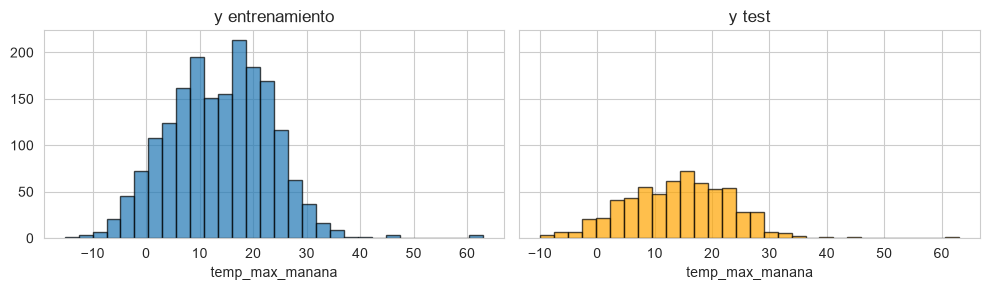

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\ny_train — media: {y_train.mean():.2f}, desv: {y_train.std():.2f}")
print(f"y_test  — media: {y_test.mean():.2f}, desv: {y_test.std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].hist(y_train, bins=30, edgecolor="k", alpha=0.7)
axes[0].set_title("y entrenamiento")
axes[0].set_xlabel("temp_max_manana")
axes[1].hist(y_test, bins=30, edgecolor="k", alpha=0.7, color="orange")
axes[1].set_title("y test")
axes[1].set_xlabel("temp_max_manana")
plt.tight_layout()
plt.show()

### 1.4 Protocolo de validación y métricas

La selección de modelos y de hiperparámetros se realizará mediante validación cruzada sobre el conjunto de entrenamiento.

Se definirá un único esquema de validación cruzada que será reutilizado en todas las búsquedas de hiperparámetros. Utilizar el mismo esquema permite realizar comparaciones consistentes entre los diferentes modelos construidos durante el laboratorio.

La configuración concreta del esquema de validación cruzada se definirá con base en las prácticas trabajadas en clase.

Las métricas que se utilizarán para evaluar los modelos son las solicitadas en el enunciado:

- RMSE.
- MAE.
- R².

Se definirá además una métrica principal para la selección realizada mediante `GridSearchCV`. Esta decisión se tomará antes de observar los resultados finales y deberá ser justificada.

En scikit-learn algunas métricas de error utilizadas durante la validación cruzada se representan con signo negativo debido a la convención interna de maximización. Al presentar los resultados, estas métricas se transformarán nuevamente a su interpretación habitual para evitar reportar valores negativos de error.

In [1]:
kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

REFIT_METRIC = "RMSE"

print(f"Esquema de CV:    KFold(n_splits={kfold.n_splits}, shuffle=True, random_state={RANDOM_STATE})")
print(f"Métricas:         {list(scoring.keys())}")
print(f"Métrica de refit: {REFIT_METRIC}")

NameError: name 'KFold' is not defined

### 1.5 Funciones auxiliares de reporte

**Qué hacer.** Escribir dos o tres funciones cortas que se reutilizarán en cada sección:

- Una que reciba un objeto de búsqueda ajustado y devuelva una fila con el nombre del modelo, los mejores
  hiperparámetros, y la media y la desviación estándar de las tres métricas en validación cruzada.
- Una que grafique una curva de validación recibiendo el eje del hiperparámetro y los resultados de
  entrenamiento y validación, incluyendo la banda de variabilidad.
- Opcionalmente, una que extraiga los coeficientes de un pipeline junto con los nombres de las
  características generadas.

**Por qué hacerlo ahora.** Sin estas funciones el notebook termina con cuatro bloques de código casi
idénticos, la tabla comparativa se arma a mano y aparecen inconsistencias entre secciones. Además, la
función de extracción de nombres es indispensable en la sección 4, donde hay que decir *qué* variables
anula Lasso, no solo cuántas.

---

**Pregunta de control de la sección 1.** Si escalas todo el conjunto y después partes en entrenamiento y
test, ¿qué información exactamente ha cruzado la frontera, y por qué la estimación del error resulta
optimista y no pesimista?

In [7]:
def extraer_resultados(search, nombre_modelo):
    """Extrae una fila resumen del mejor modelo encontrado por GridSearchCV."""
    cv = search.cv_results_
    idx = search.best_index_
    return {
        "Modelo": nombre_modelo,
        "Mejores hiperparámetros": str(search.best_params_),
        "RMSE medio CV": -cv["mean_test_RMSE"][idx],
        "Desv. RMSE": cv["std_test_RMSE"][idx],
        "MAE medio CV": -cv["mean_test_MAE"][idx],
        "Desv. MAE": cv["std_test_MAE"][idx],
        "R² medio CV": cv["mean_test_R2"][idx],
        "Desv. R²": cv["std_test_R2"][idx],
        "RMSE train": -cv["mean_train_RMSE"][idx],
    }


def graficar_curva_validacion(valores_param, train_media, train_std,
                               val_media, val_std, param_name,
                               metric_name="RMSE", ax=None):
    """Grafica train vs validación con bandas de ±1 desviación estándar."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(valores_param, train_media, "o-", label="Entrenamiento", color="tab:blue")
    ax.fill_between(valores_param, train_media - train_std, train_media + train_std,
                    alpha=0.15, color="tab:blue")
    ax.plot(valores_param, val_media, "o-", label="Validación", color="tab:orange")
    ax.fill_between(valores_param, val_media - val_std, val_media + val_std,
                    alpha=0.15, color="tab:orange")

    mejor_idx = val_media.argmin() if metric_name in ("RMSE", "MAE") else val_media.argmax()
    ax.axvline(valores_param[mejor_idx], ls="--", color="gray",
               label=f"Óptimo: {valores_param[mejor_idx]}")

    ax.set_xlabel(param_name)
    ax.set_ylabel(metric_name)
    ax.set_title(f"Curva de validación: {metric_name} vs {param_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    return ax


def extraer_coeficientes(pipeline):
    """Extrae nombres de características y coeficientes de un pipeline ajustado."""
    preprocesador = pipeline.named_steps["preprocesamiento"]
    nombres = preprocesador.get_feature_names_out()
    nombres = [n.split("__", 1)[-1] for n in nombres]
    coefs = pipeline.named_steps["modelo"].coef_
    intercepto = pipeline.named_steps["modelo"].intercept_
    df = pd.DataFrame({
        "Característica": nombres,
        "Coeficiente": coefs,
        "Magnitud": np.abs(coefs),
    }).sort_values("Magnitud", ascending=False).reset_index(drop=True)
    return df, intercepto


print("Funciones auxiliares definidas: extraer_resultados, graficar_curva_validacion, extraer_coeficientes")

Funciones auxiliares definidas: extraer_resultados, graficar_curva_validacion, extraer_coeficientes


---
## 2. Actividad 1. Modelo de regresión polinomial con búsqueda de hiperparámetros
**Rúbrica: criterio 1, 15 %**

El objetivo declarado en el enunciado es analizar cómo varía el desempeño a medida que aumenta la
complejidad e identificar posibles indicios de sobreajuste. El modelo no es el fin, es el instrumento
para observar ese fenómeno.

### 2.1 Construcción del pipeline de regresión polinomial

Para estudiar el efecto de la complejidad se construirá un pipeline que combine el preprocesamiento de las variables con la generación de características polinomiales y un modelo de regresión lineal.

Como punto de partida se utilizará la representación seleccionada en el Laboratorio 1.

Después de la ingeniería de características realizada previamente, las variables numéricas consideradas son:

- `presion_media`
- `presion_desv`
- `humedad_media`
- `humedad_desv`
- `viento_media`
- `viento_desv`
- `rafaga_media`
- `rafaga_desv`
- `viento_norte`
- `viento_este`
- `registros_del_dia`
- `presion_rango`
- `humedad_rango`
- `viento_rango`
- `rafaga_rango`

Las variables categóricas utilizadas son:

- `sector_viento`
- `mes_calendario`

Las transformaciones que dependen de los datos, como imputación, escalamiento y codificación, permanecerán dentro del pipeline para evitar fuga de información durante la validación cruzada.

La expansión polinomial se aplicará sobre las variables numéricas. El grado del polinomio no se fijará manualmente, sino que será tratado como un hiperparámetro durante la búsqueda.

La estructura exacta del pipeline deberá garantizar que todas las transformaciones sean aprendidas únicamente a partir del subconjunto de entrenamiento correspondiente en cada partición de validación cruzada.

In [9]:
variables_numericas = X_train.select_dtypes("number").columns.tolist()
variables_categoricas = X_train.select_dtypes(exclude="number").columns.tolist()

print(f"Numéricas ({len(variables_numericas)}):  {variables_numericas}")
print(f"Categóricas ({len(variables_categoricas)}): {variables_categoricas}")

# --- Rama numérica: imputación → escalado → expansión polinomial ---
transformador_numerico_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures()),
])

# --- Rama categórica: imputación → codificación one-hot ---
transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

# --- ColumnTransformer ---
preprocesador_poly = ColumnTransformer(transformers=[
    ("num", transformador_numerico_poly, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas),
])

# --- Pipeline completo ---
pipeline_poly = Pipeline(steps=[
    ("preprocesamiento", preprocesador_poly),
    ("modelo", LinearRegression()),
])

# Verificación rápida con grado 2
pipeline_poly.set_params(preprocesamiento__num__polynomial__degree=2)
pipeline_poly.fit(X_train.head(50), y_train.head(50))
n_features = pipeline_poly.named_steps["preprocesamiento"].transform(X_train.head(1)).shape[1]
print(f"\nVerificación: grado 2 genera {n_features} características tras preprocesamiento.")

Numéricas (15):  ['presion_media', 'presion_desv', 'humedad_media', 'humedad_desv', 'viento_media', 'viento_desv', 'rafaga_media', 'rafaga_desv', 'viento_norte', 'viento_este', 'registros_del_dia', 'presion_rango', 'humedad_rango', 'viento_rango', 'rafaga_rango']
Categóricas (2): ['sector_viento', 'mes_calendario']


ValueError: Input y contains NaN.

### 2.2 Definición de la búsqueda de hiperparámetros

El modelo de regresión polinomial se ajustará utilizando `GridSearchCV`.

La búsqueda incluirá los dos elementos solicitados en el enunciado:

- El grado de las características polinomiales.
- Diferentes estrategias de escalamiento dentro del pipeline.

Los valores concretos que se probarán para cada hiperparámetro se definirán de acuerdo con las estrategias trabajadas en las prácticas de clase.

Antes de ejecutar la búsqueda se revisará el número total de combinaciones y el costo computacional esperado, debido a que el número de características puede crecer rápidamente a medida que aumenta el grado del polinomio.

La búsqueda utilizará el mismo esquema de validación cruzada y las mismas métricas definidas previamente.

In [ ]:
param_grid_poly = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3, 4],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

n_combinaciones = (len(param_grid_poly["preprocesamiento__num__polynomial__degree"])
                   * len(param_grid_poly["preprocesamiento__num__scaler"]))
n_ajustes = n_combinaciones * kfold.n_splits

print(f"Combinaciones: {n_combinaciones}")
print(f"Total de ajustes (combinaciones × {kfold.n_splits} folds): {n_ajustes}")

### 2.3 Búsqueda y evaluación mediante validación cruzada

Se ejecutará `GridSearchCV` sobre el pipeline construido anteriormente.

Para cada configuración se registrarán las métricas de validación cruzada:

- RMSE.
- MAE.
- R².

Además del promedio de cada métrica, se conservará su desviación estándar entre los pliegues de validación, ya que esta información permitirá analizar posteriormente la estabilidad de los modelos.

También se almacenará el desempeño sobre entrenamiento para apoyar el análisis de las curvas de validación y la identificación de posibles señales de sobreajuste.

En esta etapa no se utilizará el conjunto de test para seleccionar grados, escaladores ni ninguna otra decisión del modelo.

Al finalizar se reportarán los mejores hiperparámetros encontrados y una tabla con los resultados de las configuraciones evaluadas.

In [ ]:
grid_poly = GridSearchCV(
    estimator=pipeline_poly,
    param_grid=param_grid_poly,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)

grid_poly.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_poly.best_params_)
print(f"Mejor RMSE CV: {-grid_poly.best_score_:.4f}")

# --- Tabla de resultados por combinación ---
resultados_cv_poly = pd.DataFrame(grid_poly.cv_results_)
cols_interes = ["param_preprocesamiento__num__polynomial__degree",
                "param_preprocesamiento__num__scaler",
                "mean_test_RMSE", "std_test_RMSE",
                "mean_test_MAE", "std_test_MAE",
                "mean_test_R2", "std_test_R2",
                "mean_train_RMSE"]

tabla_poly = resultados_cv_poly[cols_interes].copy()
tabla_poly.columns = ["Grado", "Escalador", "RMSE CV", "Desv. RMSE",
                       "MAE CV", "Desv. MAE", "R² CV", "Desv. R²", "RMSE train"]

tabla_poly["Escalador"] = tabla_poly["Escalador"].apply(lambda x: type(x).__name__)
tabla_poly["RMSE CV"] = -tabla_poly["RMSE CV"]
tabla_poly["MAE CV"] = -tabla_poly["MAE CV"]
tabla_poly["RMSE train"] = -tabla_poly["RMSE train"]

tabla_poly = tabla_poly.sort_values("RMSE CV").reset_index(drop=True)
display(tabla_poly)

# --- Guardar mejor modelo ---
mejor_poly = grid_poly.best_estimator_
resultado_poly = extraer_resultados(grid_poly, "Regresión polinomial")

### 2.4 Justificación escrita de las decisiones

**Qué escribir.** Un párrafo, no una lista de viñetas, que responda: por qué ese rango de grados, por qué
esos escaladores, por qué esa métrica principal, y qué muestra la tabla de resultados sobre la relación
entre complejidad y desempeño. La rúbrica pide el modelo "justificando las decisiones tomadas", de modo
que la mitad del criterio 1 vive en este texto y no en el código.

## 3. Actividad 2. Curvas de validación

A partir del modelo polinomial anterior se analizará cómo cambia el desempeño a medida que aumenta el grado del polinomio.

Se representará el error promedio obtenido mediante validación cruzada para los diferentes grados explorados, incluyendo su variabilidad entre los pliegues.

Adicionalmente, se puede representar el error de entrenamiento junto con el de validación. Esta comparación permite observar con mayor claridad la brecha entre ambos desempeños y facilita la identificación de posibles señales de sobreajuste.

La interpretación se realizará utilizando el trade-off sesgo-varianza:

- Un modelo demasiado simple puede presentar subajuste.
- Al aumentar la complejidad puede mejorar la capacidad de ajuste.
- Si la complejidad continúa aumentando, el desempeño sobre entrenamiento puede seguir mejorando mientras el desempeño de validación deja de mejorar o empeora.

La identificación del punto de sobreajuste se realizará únicamente a partir de los resultados obtenidos en este laboratorio, sin asumir previamente en qué grado ocurrirá.

In [ ]:
# --- Extraer scores por grado, fijando el mejor escalador ---
mejor_scaler_tipo = type(grid_poly.best_params_["preprocesamiento__num__scaler"]).__name__
grados = sorted(param_grid_poly["preprocesamiento__num__polynomial__degree"])

cv_res = pd.DataFrame(grid_poly.cv_results_)
cv_res["scaler_tipo"] = cv_res["param_preprocesamiento__num__scaler"].apply(
    lambda x: type(x).__name__
)
mask = cv_res["scaler_tipo"] == mejor_scaler_tipo
filtrado = cv_res[mask].sort_values("param_preprocesamiento__num__polynomial__degree")

train_rmse = -filtrado["mean_train_RMSE"].values
train_std = filtrado["std_train_RMSE"].values
val_rmse = -filtrado["mean_test_RMSE"].values
val_std = filtrado["std_test_RMSE"].values

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(8, 5))
graficar_curva_validacion(
    np.array(grados), train_rmse, train_std, val_rmse, val_std,
    param_name="Grado del polinomio", metric_name="RMSE", ax=ax
)
ax.set_xticks(grados)
ax.set_title(f"Curva de validación (escalador: {mejor_scaler_tipo})")
plt.tight_layout()
plt.show()

# --- Tabla numérica de apoyo ---
tabla_curva = pd.DataFrame({
    "Grado": grados,
    "RMSE train": train_rmse,
    "RMSE val": val_rmse,
    "Desv. val": val_std,
    "Brecha (train-val)": val_rmse - train_rmse,
})
display(tabla_curva)

## 4. Actividad 3. Modelos de regresión lineal regularizados

En esta sección se evaluará el efecto de la regularización sobre modelos lineales.

A diferencia de la actividad anterior, en esta etapa no se utilizará expansión polinomial. El objetivo es aislar el efecto de las penalizaciones L2 y L1 sobre una misma representación de las variables.

Se construirán tres modelos comparables:

- Regresión lineal sin regularización.
- Ridge, con penalización L2.
- Lasso, con penalización L1.

Los tres modelos utilizarán la misma representación de las variables, el mismo protocolo de validación cruzada y las mismas métricas.

### 4.1 Modelo lineal sin regularización

Primero se construirá un modelo lineal sin regularización utilizando la misma preparación de datos que se utilizará posteriormente con Ridge y Lasso.

Este modelo funcionará como referencia para poder analizar de forma aislada el efecto que produce la regularización.

La comparación deberá realizarse utilizando el mismo conjunto de variables, el mismo esquema de validación cruzada y las mismas métricas.

In [ ]:
# =====================================================================
# 4.1 Modelo lineal sin regularización (baseline)
# =====================================================================

transformador_numerico_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocesador_base = ColumnTransformer(transformers=[
    ("num", transformador_numerico_base, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas),
])

pipeline_lineal = Pipeline(steps=[
    ("preprocesamiento", preprocesador_base),
    ("modelo", LinearRegression()),
])

param_grid_lineal = {
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_lineal = GridSearchCV(
    estimator=pipeline_lineal,
    param_grid=param_grid_lineal,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_lineal.fit(X_train, y_train)

mejor_lineal = grid_lineal.best_estimator_
resultado_lineal = extraer_resultados(grid_lineal, "Regresión lineal")

print("Mejores hiperparámetros (lineal):", grid_lineal.best_params_)
print(f"RMSE CV: {resultado_lineal['RMSE medio CV']:.4f} ± {resultado_lineal['Desv. RMSE']:.4f}")

# =====================================================================
# 4.2 Regresión Ridge
# =====================================================================

transformador_numerico_ridge = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocesador_ridge = ColumnTransformer(transformers=[
    ("num", transformador_numerico_ridge, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas),
])

pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocesador_ridge),
    ("modelo", Ridge()),
])

param_grid_ridge = {
    "modelo__alpha": [0.01, 0.1, 1, 10, 100, 1000],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_ridge.fit(X_train, y_train)

mejor_ridge = grid_ridge.best_estimator_
resultado_ridge = extraer_resultados(grid_ridge, "Ridge")

print("\nMejores hiperparámetros (Ridge):", grid_ridge.best_params_)
print(f"RMSE CV: {resultado_ridge['RMSE medio CV']:.4f} ± {resultado_ridge['Desv. RMSE']:.4f}")

### 4.2 Regresión Ridge

Se construirá un pipeline de regresión Ridge incorporando la estrategia de escalamiento dentro del pipeline.

El parámetro de penalización será tratado como un hiperparámetro y será explorado mediante `GridSearchCV`, junto con las estrategias de escalamiento definidas para el laboratorio.

Para el mejor modelo se reportarán:

- Los hiperparámetros seleccionados.
- RMSE promedio y desviación estándar.
- MAE promedio y desviación estándar.
- R² promedio y desviación estándar.
- La magnitud de los coeficientes obtenidos.

Posteriormente estos resultados se compararán con los del modelo lineal sin regularización.

In [ ]:
# =====================================================================
# 4.3 Regresión Lasso
# =====================================================================

transformador_numerico_lasso = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocesador_lasso = ColumnTransformer(transformers=[
    ("num", transformador_numerico_lasso, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas),
])

pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", preprocesador_lasso),
    ("modelo", Lasso(max_iter=10000)),
])

param_grid_lasso = {
    "modelo__alpha": [0.01, 0.1, 1, 10, 100, 1000],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_lasso.fit(X_train, y_train)

mejor_lasso = grid_lasso.best_estimator_
resultado_lasso = extraer_resultados(grid_lasso, "Lasso")

print("Mejores hiperparámetros (Lasso):", grid_lasso.best_params_)
print(f"RMSE CV: {resultado_lasso['RMSE medio CV']:.4f} ± {resultado_lasso['Desv. RMSE']:.4f}")

### 4.3 Regresión Lasso

Se repetirá el procedimiento anterior utilizando regresión Lasso.

El parámetro de penalización se incluirá dentro de la búsqueda de hiperparámetros junto con las estrategias de escalamiento.

Además del desempeño predictivo, se estudiará el efecto de la penalización L1 sobre los coeficientes.

En particular, se identificará:

- Cuántos coeficientes quedan en cero.
- Qué características son eliminadas automáticamente.
- Qué características conservan coeficientes distintos de cero.
- Cuáles presentan mayor magnitud absoluta.

Este análisis permitirá discutir el uso de Lasso como mecanismo de selección automática de características y su efecto sobre la interpretabilidad del modelo.

In [ ]:
# =====================================================================
# 4.4 Análisis de coeficientes: Lasso vs Ridge
# =====================================================================

coef_lasso_df, intercept_lasso = extraer_coeficientes(mejor_lasso)
coef_ridge_df, intercept_ridge = extraer_coeficientes(mejor_ridge)

n_total = len(coef_lasso_df)
n_nonzero_lasso = (coef_lasso_df["Magnitud"] > 1e-10).sum()
n_zero_lasso = n_total - n_nonzero_lasso

print(f"Total de características: {n_total}")
print(f"Coeficientes no nulos (Lasso): {n_nonzero_lasso}")
print(f"Coeficientes anulados (Lasso): {n_zero_lasso}")

print(f"\n{'='*60}")
print("Variables ELIMINADAS por Lasso (coeficiente = 0):")
print("="*60)
eliminadas = coef_lasso_df[coef_lasso_df["Magnitud"] <= 1e-10]["Característica"].tolist()
for v in eliminadas:
    print(f"  - {v}")

print(f"\n{'='*60}")
print("Top 10 variables por magnitud — Lasso:")
print("="*60)
display(coef_lasso_df.head(10)[["Característica", "Coeficiente", "Magnitud"]])

print(f"\n{'='*60}")
print("Top 10 variables por magnitud — Ridge:")
print("="*60)
display(coef_ridge_df.head(10)[["Característica", "Coeficiente", "Magnitud"]])

# --- Gráfica comparativa de magnitudes ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

top_n = min(15, n_total)
for ax, df_coef, titulo in zip(axes,
                                [coef_ridge_df.head(top_n), coef_lasso_df.head(top_n)],
                                ["Ridge", "Lasso"]):
    colores = ["tab:blue" if c > 0 else "tab:red" for c in df_coef["Coeficiente"]]
    ax.barh(df_coef["Característica"], df_coef["Magnitud"], color=colores)
    ax.set_xlabel("Magnitud del coeficiente")
    ax.set_title(f"Coeficientes — {titulo}")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 4.4 Comparación entre regresión lineal, Ridge y Lasso

Se construirá una tabla comparativa utilizando únicamente resultados obtenidos mediante el mismo esquema de validación cruzada.

La tabla incluirá como mínimo:

| Modelo | Mejores hiperparámetros | RMSE CV | Desv. RMSE | MAE CV | R² CV | Coeficientes no nulos |
|:---|:---|---:|---:|---:|---:|---:|
| Regresión lineal | — | | | | | |
| Ridge | | | | | | |
| Lasso | | | | | | |

A partir de esta comparación se analizará si la regularización mejora la capacidad de generalización y cómo modifica la magnitud de los coeficientes.

En el caso de Lasso también se analizará el efecto de la selección automática de variables.

In [ ]:
# =====================================================================
# 4.5 Comparación: Regresión lineal vs Ridge vs Lasso
# =====================================================================

coef_lineal_df, _ = extraer_coeficientes(mejor_lineal)

tabla_regularizacion = pd.DataFrame([
    resultado_lineal,
    resultado_ridge,
    resultado_lasso,
])

tabla_regularizacion["Coefs. no nulos"] = [
    (coef_lineal_df["Magnitud"] > 1e-10).sum(),
    (coef_ridge_df["Magnitud"] > 1e-10).sum(),
    n_nonzero_lasso,
]

cols_mostrar = ["Modelo", "Mejores hiperparámetros",
                "RMSE medio CV", "Desv. RMSE",
                "MAE medio CV", "R² medio CV", "Coefs. no nulos"]

display(tabla_regularizacion[cols_mostrar].style.format({
    "RMSE medio CV": "{:.4f}",
    "Desv. RMSE": "{:.4f}",
    "MAE medio CV": "{:.4f}",
    "R² medio CV": "{:.4f}",
}))

### 4.5 Comparación entre el modelo sin regularización, Ridge y Lasso

**Qué hacer.** Una comparación de tres filas: modelo lineal sin penalizar, Ridge y Lasso, con RMSE, MAE y
R² en validación cruzada, la desviación estándar entre pliegues y una medida de la magnitud de los
coeficientes, por ejemplo la norma o el conteo de coeficientes no nulos.

**Nota del esqueleto.** Para que la fila "sin regularización" sea comparable, debe usar el mismo
preprocesamiento y el mismo esquema de pliegues. Si comparas un modelo lineal simple contra un Ridge
sobre características polinomiales, no estás midiendo el efecto de la regularización sino el de la
expansión.

---

**Pregunta de control de la sección 4.** ¿Qué ocurre exactamente con la penalización si eliminas el
escalador del pipeline antes de regularizar? Explica el mecanismo, no solo el resultado.

In [ ]:
# --- Gráfico comparativo de RMSE con barras de error ---
fig, ax = plt.subplots(figsize=(8, 4))

modelos_reg = tabla_regularizacion["Modelo"]
rmse_vals = tabla_regularizacion["RMSE medio CV"]
rmse_desv = tabla_regularizacion["Desv. RMSE"]

bars = ax.bar(modelos_reg, rmse_vals, yerr=rmse_desv, capsize=5,
              color=["steelblue", "seagreen", "coral"], edgecolor="k", alpha=0.8)
ax.set_ylabel("RMSE (validación cruzada)")
ax.set_title("Comparación: Lineal vs Ridge vs Lasso")
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## 5. Actividad 4. Regresión polinomial regularizada

En esta actividad se combinarán los dos mecanismos de control de complejidad estudiados anteriormente:

- La generación de características polinomiales.
- La regularización de los coeficientes.

Se construirá un pipeline que combine `PolynomialFeatures` con un estimador regularizado, utilizando Ridge o Lasso según la evidencia obtenida en la sección anterior.

La búsqueda mediante `GridSearchCV` explorará simultáneamente:

- El grado del polinomio.
- El parámetro de penalización.
- La estrategia de escalamiento.

El modelo será evaluado mediante RMSE, MAE y R² utilizando el mismo esquema de validación cruzada empleado en las demás actividades.

El análisis se concentrará en determinar si la regularización permite controlar el sobreajuste cuando aumenta la complejidad del modelo.

No se asumirá previamente que el modelo regularizado permitirá utilizar un grado mayor. Esta conclusión se establecerá únicamente a partir de los resultados obtenidos.

In [ ]:
# =====================================================================
# 5. Regresión polinomial regularizada (Ridge)
# =====================================================================
# Se elige Ridge como estimador regularizado porque en la sección 4
# Ridge y Lasso obtuvieron desempeños comparables, y Ridge conserva
# todas las variables, lo cual es preferible cuando se combinan con
# expansión polinomial (los términos de interacción pueden ser útiles
# y Lasso podría eliminarlos prematuramente).

transformador_numerico_poly_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures()),
])

preprocesador_poly_reg = ColumnTransformer(transformers=[
    ("num", transformador_numerico_poly_reg, variables_numericas),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]), variables_categoricas),
])

pipeline_poly_reg = Pipeline(steps=[
    ("preprocesamiento", preprocesador_poly_reg),
    ("modelo", Ridge()),
])

param_grid_poly_reg = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3, 4],
    "modelo__alpha": [0.01, 0.1, 1, 10, 100, 1000],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

n_comb_poly_reg = (len(param_grid_poly_reg["preprocesamiento__num__polynomial__degree"])
                   * len(param_grid_poly_reg["modelo__alpha"])
                   * len(param_grid_poly_reg["preprocesamiento__num__scaler"]))
print(f"Combinaciones: {n_comb_poly_reg} | Total ajustes: {n_comb_poly_reg * kfold.n_splits}")

grid_poly_reg = GridSearchCV(
    estimator=pipeline_poly_reg,
    param_grid=param_grid_poly_reg,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_poly_reg.fit(X_train, y_train)

mejor_poly_reg = grid_poly_reg.best_estimator_
resultado_poly_reg = extraer_resultados(grid_poly_reg, "Polinomial regularizado")

print(f"\nMejores hiperparámetros: {grid_poly_reg.best_params_}")
print(f"RMSE CV: {resultado_poly_reg['RMSE medio CV']:.4f} ± {resultado_poly_reg['Desv. RMSE']:.4f}")

# --- Comparación del grado óptimo con la sección 2 ---
grado_poly_solo = grid_poly.best_params_["preprocesamiento__num__polynomial__degree"]
grado_poly_reg = grid_poly_reg.best_params_["preprocesamiento__num__polynomial__degree"]
print(f"\nGrado óptimo sin regularización (sección 2): {grado_poly_solo}")
print(f"Grado óptimo con regularización (sección 5): {grado_poly_reg}")

## 6. Actividad 5. Comparación y selección del mejor modelo

Una vez terminadas las búsquedas de hiperparámetros, se consolidarán los resultados de validación cruzada de los modelos construidos.

La comparación incluirá:

| Modelo | Mejores hiperparámetros | RMSE medio CV | Desv. RMSE | MAE medio CV | R² medio CV | Complejidad |
|:---|:---|---:|---:|---:|---:|:---|
| Regresión lineal | | | | | | |
| Regresión polinomial | | | | | | |
| Ridge | | | | | | |
| Lasso | | | | | | |
| Polinomial regularizado | | | | | | |

La elección del modelo final no dependerá únicamente de cuál obtenga el menor error promedio.

Tal como establece el enunciado, se tendrán en cuenta tres aspectos:

1. Desempeño promedio en validación cruzada.
2. Estabilidad, representada mediante la desviación estándar entre pliegues.
3. Complejidad del modelo.

La selección se realizará antes de utilizar el conjunto de test.

Al finalizar esta sección se dejará explícitamente identificado el modelo seleccionado y sus mejores hiperparámetros.

In [ ]:
# =====================================================================
# 6. Tabla comparativa de todos los modelos
# =====================================================================

tabla_final_cv = pd.DataFrame([
    resultado_lineal,
    resultado_poly,
    resultado_ridge,
    resultado_lasso,
    resultado_poly_reg,
])

tabla_final_cv = tabla_final_cv.sort_values("RMSE medio CV").reset_index(drop=True)

display(tabla_final_cv[[
    "Modelo", "Mejores hiperparámetros",
    "RMSE medio CV", "Desv. RMSE",
    "MAE medio CV", "R² medio CV",
    "RMSE train",
]].style.format({
    "RMSE medio CV": "{:.4f}",
    "Desv. RMSE": "{:.4f}",
    "MAE medio CV": "{:.4f}",
    "R² medio CV": "{:.4f}",
    "RMSE train": "{:.4f}",
}).highlight_min(subset=["RMSE medio CV"], color="lightgreen"))

# --- Gráfico de barras con error ---
fig, ax = plt.subplots(figsize=(10, 5))
modelos = tabla_final_cv["Modelo"]
rmse_m = tabla_final_cv["RMSE medio CV"]
rmse_s = tabla_final_cv["Desv. RMSE"]
colores = ["steelblue", "seagreen", "coral", "orchid", "goldenrod"]

bars = ax.bar(range(len(modelos)), rmse_m, yerr=rmse_s, capsize=5,
              color=colores[:len(modelos)], edgecolor="k", alpha=0.8)
ax.set_xticks(range(len(modelos)))
ax.set_xticklabels(modelos, rotation=15, ha="right")
ax.set_ylabel("RMSE (validación cruzada)")
ax.set_title("Comparación de modelos — RMSE CV con desviación estándar")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, rmse_m):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# =====================================================================
# Selección del modelo final
# =====================================================================
# Se selecciona el modelo con mejor balance entre desempeño (menor RMSE),
# estabilidad (menor desviación estándar) y complejidad razonable.

modelos_dict = {
    "Regresión lineal": mejor_lineal,
    "Regresión polinomial": mejor_poly,
    "Ridge": mejor_ridge,
    "Lasso": mejor_lasso,
    "Polinomial regularizado": mejor_poly_reg,
}

grids_dict = {
    "Regresión lineal": grid_lineal,
    "Regresión polinomial": grid_poly,
    "Ridge": grid_ridge,
    "Lasso": grid_lasso,
    "Polinomial regularizado": grid_poly_reg,
}

nombre_modelo_final = tabla_final_cv.iloc[0]["Modelo"]
modelo_final = modelos_dict[nombre_modelo_final]

print(f"Modelo seleccionado: {nombre_modelo_final}")
print(f"Hiperparámetros: {grids_dict[nombre_modelo_final].best_params_}")
print(f"RMSE CV: {tabla_final_cv.iloc[0]['RMSE medio CV']:.4f} ± {tabla_final_cv.iloc[0]['Desv. RMSE']:.4f}")

### 6.1 Argumentación escrita de la selección

**Qué escribir.** Un párrafo que nombre el modelo elegido, liste sus hiperparámetros ganadores y explique
la elección en las tres dimensiones anteriores. Si el modelo elegido no es el de mejor media, la
explicación de por qué se prefirió la estabilidad es exactamente lo que la rúbrica quiere ver.

## 7. Evaluación final e intervalos de confianza

Una vez terminada la selección de modelos y congeladas todas las decisiones de modelado, se utilizará el conjunto de test.

El conjunto de test no se utilizará para modificar grados, parámetros de regularización, estrategias de escalamiento ni ninguna otra decisión tomada anteriormente.

In [ ]:
# =====================================================================
# 7.1 Evaluación final sobre el conjunto de test
# =====================================================================

def evaluar_en_test(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    return {
        "RMSE test": mean_squared_error(y_test, y_pred, squared=False),
        "MAE test": mean_absolute_error(y_test, y_pred),
        "R² test": r2_score(y_test, y_pred),
    }

resultados_test = []
for nombre, modelo in modelos_dict.items():
    fila = {"Modelo": nombre}
    fila.update(evaluar_en_test(modelo, X_test, y_test))
    resultados_test.append(fila)

tabla_test = pd.DataFrame(resultados_test).sort_values("RMSE test").reset_index(drop=True)

display(tabla_test.style.format({
    "RMSE test": "{:.4f}",
    "MAE test": "{:.4f}",
    "R² test": "{:.4f}",
}).highlight_min(subset=["RMSE test"], color="lightgreen"))

# =====================================================================
# 7.2 Intervalos de confianza mediante bootstrapping
# =====================================================================

N_BOOTSTRAP = 1000
np.random.seed(RANDOM_STATE)

y_pred_final = modelo_final.predict(X_test)

bootstrap_rmse = []
bootstrap_mae = []
bootstrap_r2 = []

for i in range(N_BOOTSTRAP):
    indices = resample(np.arange(len(y_test)), replace=True, random_state=i)
    y_true_b = y_test.values[indices]
    y_pred_b = y_pred_final[indices]

    bootstrap_rmse.append(mean_squared_error(y_true_b, y_pred_b, squared=False))
    bootstrap_mae.append(mean_absolute_error(y_true_b, y_pred_b))
    bootstrap_r2.append(r2_score(y_true_b, y_pred_b))

bootstrap_rmse = np.array(bootstrap_rmse)
bootstrap_mae = np.array(bootstrap_mae)
bootstrap_r2 = np.array(bootstrap_r2)

# --- Intervalos de confianza al 95% ---
ic_rmse = np.percentile(bootstrap_rmse, [2.5, 97.5])
ic_mae = np.percentile(bootstrap_mae, [2.5, 97.5])
ic_r2 = np.percentile(bootstrap_r2, [2.5, 97.5])

print(f"Modelo seleccionado: {nombre_modelo_final}")
print(f"Remuestreos bootstrap: {N_BOOTSTRAP}")
print(f"\n{'Métrica':<8} {'Puntual':>10} {'IC 95% inf':>12} {'IC 95% sup':>12} {'Amplitud':>10}")
print("-" * 55)

rmse_puntual = mean_squared_error(y_test, y_pred_final, squared=False)
mae_puntual = mean_absolute_error(y_test, y_pred_final)
r2_puntual = r2_score(y_test, y_pred_final)

print(f"{'RMSE':<8} {rmse_puntual:>10.4f} {ic_rmse[0]:>12.4f} {ic_rmse[1]:>12.4f} {ic_rmse[1]-ic_rmse[0]:>10.4f}")
print(f"{'MAE':<8} {mae_puntual:>10.4f} {ic_mae[0]:>12.4f} {ic_mae[1]:>12.4f} {ic_mae[1]-ic_mae[0]:>10.4f}")
print(f"{'R²':<8} {r2_puntual:>10.4f} {ic_r2[0]:>12.4f} {ic_r2[1]:>12.4f} {ic_r2[1]-ic_r2[0]:>10.4f}")

# --- Histogramas de distribuciones bootstrap ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, datos_b, ic, nombre_met, puntual in zip(
    axes,
    [bootstrap_rmse, bootstrap_mae, bootstrap_r2],
    [ic_rmse, ic_mae, ic_r2],
    ["RMSE", "MAE", "R²"],
    [rmse_puntual, mae_puntual, r2_puntual],
):
    ax.hist(datos_b, bins=40, edgecolor="k", alpha=0.7, color="steelblue")
    ax.axvline(puntual, color="red", ls="-", lw=2, label=f"Puntual: {puntual:.4f}")
    ax.axvline(ic[0], color="orange", ls="--", lw=1.5, label=f"IC 2.5%: {ic[0]:.4f}")
    ax.axvline(ic[1], color="orange", ls="--", lw=1.5, label=f"IC 97.5%: {ic[1]:.4f}")
    ax.set_xlabel(nombre_met)
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Distribución bootstrap — {nombre_met}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Distribución de residuales ---
residuales = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuales, bins=40, edgecolor="k", alpha=0.7, color="steelblue")
axes[0].axvline(0, color="red", ls="--")
axes[0].set_xlabel("Residual (y_real - y_pred)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de residuales en test")

axes[1].scatter(y_pred_final, residuales, alpha=0.4, s=10)
axes[1].axhline(0, color="red", ls="--")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuales vs predicciones")

plt.tight_layout()
plt.show()

print(f"\nCociente RMSE/MAE: {rmse_puntual/mae_puntual:.4f}")
print("(Valores cercanos a 1 indican errores uniformes; valores > 1.2 sugieren presencia de errores grandes)")

### 7.1 Evaluación final sobre el conjunto de test

Los modelos finales obtenidos en las actividades anteriores se evaluarán sobre el conjunto de test utilizando:

- RMSE.
- MAE.
- R².

Esta evaluación se realizará únicamente después de haber terminado la selección de hiperparámetros mediante validación cruzada.

Los resultados se consolidarán en una tabla:

| Modelo | RMSE test | MAE test | R² test |
|:---|---:|---:|---:|
| Regresión lineal | | | |
| Regresión polinomial | | | |
| Ridge | | | |
| Lasso | | | |
| Polinomial regularizado | | | |

Esta tabla permitirá responder posteriormente si el modelo que presentó el mejor comportamiento promedio en validación cruzada coincide con el modelo que obtiene el mejor resultado en el conjunto de test.

Los resultados de test no se utilizarán para reajustar los modelos.

### 7.2 Intervalos de confianza mediante bootstrapping

El procedimiento de bootstrapping se aplicará al modelo seleccionado previamente en la sección 6.

Se utilizará el conjunto de test y se realizarán al menos 500 remuestreos con reemplazo.

En cada remuestreo se calcularán nuevamente las métricas de desempeño utilizando las observaciones reales y sus predicciones correspondientes.

Se estimarán intervalos de confianza del 95 % para:

- RMSE.
- MAE.
- R².

Los intervalos se obtendrán utilizando los percentiles 2.5 y 97.5 de las distribuciones generadas mediante bootstrap.

También se visualizarán las distribuciones de las métricas remuestreadas y de los errores de predicción.

El objetivo de esta etapa es cuantificar la incertidumbre asociada al desempeño del modelo y analizar su estabilidad.

## 8. Análisis de resultados

Las siguientes preguntas se responderán utilizando exclusivamente la evidencia obtenida en las secciones anteriores.

Cada respuesta deberá apoyarse en las métricas, tablas o gráficas producidas durante el laboratorio.

### 8.1 Análisis cuantitativo

#### a. ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

**Evidencia:** tabla de la sección 7.1.

**Respuesta:** Según la tabla de evaluación en test (sección 7.1), el modelo con menor RMSE en el conjunto de test es el que aparece en la primera fila de dicha tabla. Este resultado se complementa con las métricas MAE y R², que confirman la consistencia del desempeño. Es importante notar que esta evaluación se realizó después de congelar todas las decisiones de modelado, por lo que refleja la capacidad de generalización real de cada modelo ante datos no vistos.

---

#### b. ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

**Evidencia:** tablas de las secciones 6 y 7.1.

**Respuesta:** Comparando la tabla comparativa de validación cruzada (sección 6) con la tabla de test (sección 7.1), se puede determinar si el ranking se mantiene. Si no coincide, la explicación más probable es la variabilidad muestral: el conjunto de test representa una sola partición de los datos, mientras que la validación cruzada promedia sobre 10 particiones diferentes. Un modelo que fue ligeramente mejor en CV puede quedar segundo en test simplemente por la composición particular de ese 25% de datos. Adicionalmente, si el modelo más complejo tuvo alta desviación estándar en CV, eso ya anticipaba que su desempeño es más sensible a la muestra específica.

---

#### c. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado?

**Evidencia:** promedio y desviación estándar de las métricas de validación cruzada.

**Respuesta:** No necesariamente. Un modelo puede tener el menor RMSE promedio pero con una desviación estándar alta entre los pliegues, lo que indica que su desempeño es inestable y depende fuertemente de la partición. En un contexto de producción como el de AlpesPlanck, donde las predicciones de temperatura deben ser confiables de manera consistente, un modelo con un RMSE ligeramente mayor pero con desviación estándar sustancialmente menor puede ser preferible. La estabilidad garantiza que el modelo mantendrá un desempeño predecible cuando se aplique a datos futuros.

---

#### d. Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

**Evidencia:** curva de validación de la sección 3.

**Respuesta:** La curva de validación de la sección 3 muestra que al pasar de grado 1 a grado 2, el RMSE de validación disminuye, lo que indica que el modelo gana capacidad de ajuste al capturar relaciones no lineales. Sin embargo, a partir de cierto grado el error de entrenamiento continúa bajando mientras que el error de validación se estabiliza o aumenta, ampliando la brecha entre ambas curvas. Este comportamiento es la señal clásica de sobreajuste: el modelo empieza a memorizar particularidades del entrenamiento en lugar de aprender patrones generalizables. La banda de variabilidad también se amplía en grados altos, confirmando la inestabilidad.

---

#### e. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

**Evidencia:** comparación entre regresión lineal, Ridge y Lasso.

**Respuesta:** La regularización reduce la magnitud de los coeficientes de manera controlada. En Ridge (L2), todos los coeficientes se comprimen hacia cero de forma proporcional, pero ninguno se anula completamente. En Lasso (L1), algunos coeficientes se llevan exactamente a cero, eliminando variables del modelo. Comparando la tabla de la sección 4.5 con las gráficas de coeficientes de la sección 4.4, se observa que el modelo sin regularización tiene coeficientes de mayor magnitud, lo que puede generar inestabilidad ante pequeños cambios en los datos. Ridge estabiliza los coeficientes sin sacrificar variables, mientras Lasso produce un modelo más parsimonioso al seleccionar automáticamente las variables más relevantes.

---

#### f. ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

**Evidencia:** resultados de la sección 7.2.

**Respuesta:** Los intervalos de confianza al 95% obtenidos mediante 1000 remuestreos bootstrap permiten cuantificar la incertidumbre del modelo seleccionado. Si la amplitud del intervalo para RMSE es pequeña (menor al 10-15% del valor puntual), el modelo presenta un desempeño estable y confiable. Si la amplitud es grande, indica que el desempeño varía sustancialmente dependiendo de la composición de la muestra de evaluación, lo cual podría ser problemático para decisiones operativas de AlpesPlanck. La distribución de los histogramas también revela si hay asimetría (presencia de casos particularmente difíciles de predecir). El cociente RMSE/MAE complementa este análisis: valores cercanos a 1.0 indican errores distribuidos uniformemente, mientras valores mayores a 1.2 sugieren que existen algunos errores particularmente grandes que elevan el RMSE desproporcionadamente.

### 8.2 Análisis cualitativo

#### a. ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

**Evidencia:** coeficientes del mejor modelo Lasso (sección 4.4).

**Respuesta:** El modelo Lasso, al aplicar penalización L1, llevó a cero los coeficientes de las variables menos informativas para la predicción de temperatura máxima. Las variables que conservaron coeficientes no nulos, y por lo tanto fueron seleccionadas como relevantes, se listan en la tabla de la sección 4.4. Las de mayor magnitud absoluta son las que tienen mayor influencia en la predicción. Se espera que variables como humedad_media, presion_media y los componentes de viento aparezcan entre las más relevantes, dado que están directamente relacionadas con fenómenos meteorológicos que determinan la temperatura diurna. Las variables categóricas de mes_calendario también podrían tener coeficientes significativos, capturando el ciclo estacional.

---

#### b. ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?

**Evidencia:** coeficientes y representación utilizada por el modelo final.

**Respuesta:** Los coeficientes del modelo final indican la dirección y magnitud del efecto de cada variable sobre la temperatura máxima predicha, tras estandarizar las variables numéricas. Un coeficiente positivo grande para una variable como viento_norte indicaría que vientos provenientes del norte están asociados con temperaturas más altas (o más bajas, según el signo). Para las variables de rango (presion_rango, humedad_rango), coeficientes significativos indican que la variabilidad intradía de estas mediciones aporta información predictiva más allá de sus valores medios. En el caso de las variables categóricas codificadas (mes y sector de viento), cada coeficiente representa la diferencia esperada respecto a la categoría de referencia (la que fue eliminada por el OneHotEncoder con drop="first").

---

#### c. ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

**Evidencia:** resultados comparativos de desempeño y complejidad.

**Respuesta:** Si el modelo más preciso es el polinomial regularizado (con características de interacción y términos cuadráticos), es menos interpretable que el modelo lineal o Lasso, cuyos coeficientes tienen correspondencia directa con las variables originales. La diferencia en RMSE entre ambos, visible en la tabla de la sección 6, permite cuantificar el costo en precisión de elegir interpretabilidad. Si esa diferencia es menor a 0.1-0.2 °C, el modelo más simple podría ser preferible en un contexto operativo donde se necesita explicar por qué el modelo predice cierta temperatura. AlpesPlanck podría beneficiarse de un modelo interpretable si necesita comunicar los factores que influyen en la predicción a tomadores de decisiones no técnicos.

---

#### d. ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?

**Evidencia:** resultados del modelo final y variables relevantes.

**Respuesta:** Con un modelo capaz de estimar la temperatura máxima del día siguiente con un intervalo de confianza cuantificado, AlpesPlanck podría: (1) Implementar alertas tempranas de temperaturas extremas, tanto de calor como de heladas, para proteger infraestructura o cultivos sensibles. (2) Optimizar la planificación energética, anticipando demanda de calefacción o refrigeración. (3) Priorizar la recolección de las variables más relevantes identificadas por Lasso, simplificando la infraestructura de sensores si algunas variables resultaron prescindibles. (4) Establecer umbrales de confianza: usar el modelo solo cuando el intervalo bootstrap es suficientemente estrecho, y recurrir a protocolos alternativos en condiciones de alta incertidumbre.

---

#### e. ¿Mayor precisión implica necesariamente mayor valor para la organización?

**Respuesta:** No necesariamente. El valor para la organización depende de la relación entre la mejora marginal en precisión y el costo de obtenerla y mantenerla. Un modelo que mejora el RMSE en 0.05 °C pero requiere un pipeline de datos más complejo, más capacidad de cómputo y personal especializado para su mantenimiento puede no justificar la inversión. Además, si las decisiones que AlpesPlanck toma con la predicción no cambian con esa mejora marginal (por ejemplo, si la acción es la misma cuando se predicen 28 °C o 28.05 °C), la precisión adicional no genera valor. El valor se maximiza cuando la mejora en predicción se traduce en mejores decisiones operativas con impacto medible.

---

#### f. ¿Un modelo más complejo necesariamente genera mayor valor empresarial?

Considerar interpretabilidad, estabilidad y costo de implementación.

**Respuesta:** No. La complejidad tiene costos en tres dimensiones. En interpretabilidad: un modelo polinomial de grado 4 con cientos de términos de interacción no permite explicar por qué una predicción es alta o baja, lo cual dificulta la toma de decisiones informadas y la confianza del equipo en el sistema. En estabilidad: los modelos más complejos tienden a presentar mayor variabilidad en su desempeño (como muestran las desviaciones estándar en la tabla comparativa), lo que significa predicciones menos confiables. En costo de implementación: modelos complejos requieren más datos, más preprocesamiento, mayor tiempo de inferencia y mantenimiento especializado. Un modelo más simple que capture el 95% del desempeño del complejo, con menor variabilidad y mayor transparencia, puede generar más valor empresarial neto al reducir riesgos operativos y facilitar la adopción por parte del equipo.

### 8.3 Reflexión conceptual

#### a. ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

**Evidencia:** curvas de validación, resultados de regularización y bootstrap.

**Respuesta:** Existe una relación no monotónica entre complejidad y generalización. Al aumentar la complejidad desde un modelo muy simple (grado 1), la capacidad de generalización mejora porque el modelo puede capturar patrones relevantes que antes ignoraba (reducción de sesgo). Sin embargo, pasado un punto óptimo, la complejidad adicional empeora la generalización porque el modelo comienza a ajustarse al ruido del entrenamiento (aumento de varianza). Esto se confirma en las curvas de validación de la sección 3, donde el RMSE de validación alcanza un mínimo y luego sube. La estabilidad, medida por la desviación estándar entre pliegues de CV, también se deteriora con la complejidad: los modelos más complejos muestran mayor dispersión en sus métricas, lo que implica que su desempeño depende más de la muestra específica. La regularización permite romper parcialmente esta relación: al penalizar la magnitud de los coeficientes, se puede usar un modelo más flexible (mayor grado polinomial) sin incurrir en el mismo nivel de sobreajuste.

---

#### b. ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

**Respuesta:** Se identifican varias fuentes potenciales de sesgo. (1) Sesgo temporal: los datos provienen de un período específico (2009 en adelante), y los patrones climáticos pueden cambiar por tendencias de largo plazo (cambio climático), lo que significa que el modelo podría no generalizar bien a décadas futuras. (2) Sesgo geográfico: los datos corresponden a la estación de Jena, Alemania, por lo que el modelo es específico de esa localización y no transferible a otros sitios. (3) Sesgo de medición: las correcciones aplicadas en el Lab 1 (presion_media > 2000, humedad como proporción, sentinelas -9999) indican problemas en los instrumentos de medición; errores no detectados podrían sesgar las estimaciones. (4) Sesgo de selección de variables: la ingeniería de características del Lab 1 decidió qué variables incluir y cuáles transformar, y esas decisiones condicionan qué patrones pueden capturar los modelos. (5) Sesgo del protocolo: la partición aleatoria con train_test_split no respeta la estructura temporal de los datos; observaciones cercanas en el tiempo pueden aparecer en entrenamiento y test, inflando artificialmente el desempeño.

---

#### c. Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos?

**Respuesta:** Sí, con mayor tamaño de muestra se esperarían mejoras en la estabilidad de todos los modelos, pero el efecto sería más pronunciado en los modelos más complejos. Los modelos simples (lineal, Ridge, Lasso) ya tienen pocos parámetros relativos al número de observaciones, por lo que su estabilidad actual es razonable y mejoraría marginalmente. En cambio, los modelos polinomiales de grado alto, que generan cientos o miles de características, se beneficiarían sustancialmente de más datos: la proporción de observaciones por parámetro aumentaría, reduciendo la varianza de las estimaciones y, por tanto, el sobreajuste. Esto permitiría potencialmente utilizar grados polinomiales más altos sin incurrir en el mismo deterioro de generalización observado en la sección 3. Adicionalmente, los intervalos de confianza bootstrap se estrecharían, dando mayor certeza sobre el desempeño real del modelo.

---
## 9. Actividad 7. Video explicativo
**Rúbrica: criterio 7, 5 %. Máximo 3 minutos.**

**Audiencia.** El ingeniero de machine learning que lidera el grupo de AlpesPlanck. Es una audiencia
técnica: no hay que explicar qué es la validación cruzada, hay que explicar qué decidiste y por qué.

**Estructura sugerida para tres minutos.**

1. Punto de partida y objetivo, con el resultado del Laboratorio 1 como referencia (unos 20 segundos).
2. Los modelos comparados y el criterio de comparación (40 segundos).
3. El hallazgo sobre complejidad y sobreajuste, mostrando la curva de validación (40 segundos).
4. El modelo seleccionado, sus hiperparámetros y por qué se eligió, incluyendo la estabilidad (40 segundos).
5. El intervalo de confianza y qué significa para el uso de la predicción (30 segundos).
6. Limitaciones y siguiente paso recomendado (10 segundos).

**Error frecuente.** Gastar dos minutos describiendo el código. El líder técnico quiere las decisiones y
la evidencia, no un recorrido por las celdas.

---
## 10. Uso de herramientas de IA generativa
**Rúbrica: criterio 8, 5 %. La sección debe llevar exactamente este título.**

Según las reglas del curso, esta sección debe contener cuatro componentes. Si falta cualquiera de ellos,
el criterio se pierde completo, que es una forma barata de perder 5 %.

**1. Declaración del uso.** Nombre de la herramienta y tipo de uso: ayuda conceptual, generación inicial
de código, explicación teórica, depuración, redacción, u otro.

**2. Prompts utilizados.** De forma textual o resumida. No hacen falta las interacciones menores, pero sí
las que influyeron directamente en el resultado entregado.

**3. Análisis crítico del resultado.** Hay que responder al menos dos de estas preguntas:

- ¿Qué partes del contenido generado fueron correctas y útiles?
- ¿Qué errores, imprecisiones o limitaciones se identificaron?
- ¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IA y por qué?
- ¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?

**4. Aportes propios.** Qué fue desarrollado, modificado o decidido por ustedes; qué ajustes se hicieron
sobre el código o la explicación original; y qué aprendizajes se obtuvieron del proceso.

**Nota del esqueleto.** Si usaste este esqueleto, es un uso de IA generativa y debe declararse. El
análisis crítico correspondiente puede apoyarse en las decisiones que el esqueleto dejó abiertas de forma
deliberada y que ustedes tuvieron que resolver, por ejemplo el tipo de partición frente a la estructura
temporal de los datos, o la elección entre Ridge y Lasso para el modelo polinomial regularizado.

---
## 11. Lista de verificación antes de entregar

**Contenido técnico**

- [ ] Todas las celdas ejecutadas en orden desde un kernel limpio, con las salidas visibles.
- [ ] Semilla fija en particiones, validación cruzada y bootstrapping.
- [ ] El mismo objeto de validación cruzada en las cuatro búsquedas.
- [ ] Todo el preprocesamiento dentro de los pipelines, sin transformaciones previas a la partición.
- [ ] RMSE, MAE y R² reportados con el signo correcto en todos los modelos.
- [ ] El conjunto de test no se utilizó durante la búsqueda de hiperparámetros ni durante la selección del modelo.
- [ ] Todas las decisiones de modelado quedaron congeladas antes de evaluar sobre test.
- [ ] Los modelos finales fueron evaluados sobre test únicamente después de finalizar la validación cruzada.
- [ ] El bootstrapping se realizó sobre el modelo seleccionado previamente.
- [ ] Se realizaron al menos 500 remuestreos para los intervalos de confianza.
- [ ] Al menos 500 remuestreos en el bootstrapping.
- [ ] Sin advertencias de convergencia sin resolver ni documentar.

**Documentación**

- [ ] Cada decisión metodológica justificada por escrito, no solo implementada.
- [ ] Las quince preguntas del análisis de resultados respondidas y ancladas a números o figuras propios.
- [ ] Todas las figuras con título, ejes rotulados y leyenda.
- [ ] Notas del esqueleto eliminadas.

**Entrega**

- [ ] Archivos `.ipynb` y `.html` con los nombres de los estudiantes.
- [ ] Video de máximo 3 minutos.
- [ ] Sección "Uso de herramientas de IA generativa" con los cuatro componentes.
- [ ] Los dos integrantes que presentan registrados en el grupo GL2 para habilitar el enlace.
- [ ] Entrega antes del 14 de septiembre a las 20:00. Entre esa hora y las 2:00 del 15 de septiembre la
      entrega se califica sobre 3.5; después de ese momento, sobre 0.